<a href="https://colab.research.google.com/github/agroimpacts/adleo/blob/main/assignments/assignment3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Assignment 3 - Fine-tuning and Inference (prediction)

## Instructions

Please follow the [instructions](assignments-setup.qmd) for setting up, completing, and submitting your assignments.

## Assignment Overview

The focus of this assignment is on model deployment, fine-tuning, and evaluation using the models you developed in Assignment 2.

In Assignment 2, you built complete training pipelines for both image classification and semantic segmentation tasks. In this assignment, you will move beyond model construction and focus on:

- Performing inference with trained models

- Applying fine-tuning strategies

- Evaluating model performance using appropriate metrics

- Interpreting segmentation outputs quantitatively

After completing this assignment, you will understand how to:

- Transition from training mode to inference mode correctly in PyTorch

- Apply transfer learning and fine-tuning strategies

- Compute and interpret evaluation metrics for semantic segmentation

- Compare model performance using quantitative measures

This assignment emphasizes model evaluation and performance analysis, which are essential components of any real-world deep learning workflow.

**Note:** To perform the analyses here, as with Assignment 2, you will need to have either a locally capable GPU or have a Colab Pro subscription.  

## Assignment

Follow the instructions below to complete your coding assignment.

Run the code in the sections beginning with "Static" unchanged, unless otherwise indicated.

### Static code 1

In [ ]:
# @title Mount drive and run imports
from google.colab import drive
drive.mount("/content/gdrive")

In [ ]:
# @title Importing Necessary Packages

import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import models
import torch.nn.functional as F


import torchvision.transforms as transforms
from torchvision.transforms import v2
import torchvision.datasets as datasets
import torch.utils.data as data
import copy

import matplotlib.pyplot as plt
import cv2
import numpy as np
import random
import numbers

import pandas as pd
import os

from pathlib import Path

from torch.utils.data import Dataset, DataLoader
import rasterio

import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from pathlib import Path
from matplotlib.patches import Patch



# function to ensure reproducibility by fixing random state
def set_seed(seed_value):
    """Set seed for reproducibility."""
    random.seed(seed_value)
    np.random.seed(seed_value)
    torch.manual_seed(seed_value)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed_value)
        torch.cuda.manual_seed_all(seed_value)
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False

set_seed(1)

### Task 1

#### **Run inference on your trained MNIST ResNet18 model (no training in this assignment) (steps 1.1-1.3)**

In this task, you will evaluate the ResNet18 model you trained and saved in Assignment 2.

Switch the model to evaluation mode using `model.eval()` and run inference using `torch.no_grad()` against the model test split.

Compute and print the overall accuracy.


#### Step 1.1: Load the MNIST test dataset and Rebuild the ResNet18


- Load the MNIST test dataset only and create a `test_loader` (you've learned this part in the first assignment).


- Rebuild the same ResNet18 architecture used in Assignment 2 (you'de learned this part in the second assignment):

  - Modify the first convolution layer to accept 1-channel MNIST images.

  - Modify the final fully connected layer to output 10 classes.

In [2]:
# @title Save path

## Modify to the path as needed in your pipeline
save_dir = "../data/MNIST"
model_dir = "../data/resnet18_mnist.pth"


In [3]:
## Answer here (data related)
mnist_mean = 0.13066048920154572
mnist_std = 0.30810779333114624

# Transforms
train_transforms = v2.Compose([
    v2.RandomRotation(degrees=5, fill=0),
    v2.RandomCrop(size=28, padding=2),
    v2.ToImage(),
    v2.ToDtype(torch.float32, scale=True),
    v2.Normalize(mean=[mnist_mean], std=[mnist_std]),
])

test_transforms = v2.Compose([
    v2.ToImage(),
    v2.ToDtype(torch.float32, scale=True),
    v2.Normalize(mean=[mnist_mean], std=[mnist_std]),
])

# Datasets
train_data = datasets.MNIST(root=save_dir, train=True, transform=train_transforms, download=True)
test_data  = datasets.MNIST(root=save_dir, train=False, transform=test_transforms, download=True)

# Train/val split (90/10)
train_size = int(0.9 * len(train_data))
val_size   = len(train_data) - train_size
train_data, validate_data = data.random_split(train_data, [train_size, val_size])

validate_data = copy.deepcopy(validate_data)
validate_data.dataset.transform = test_transforms

test_loader     = DataLoader(test_data,     batch_size=50, shuffle=False)



In [4]:
## Answer here (model-related, from the second assignment)
model = models.resnet18(weights=None)

# Modify input layer: 3-channel → 1-channel
model.conv1 = nn.Conv2d(
    in_channels=1,
    out_channels=model.conv1.out_channels,
    kernel_size=model.conv1.kernel_size,
    stride=model.conv1.stride,
    padding=model.conv1.padding,
    bias=model.conv1.bias is not None
)

# Modify output layer: 1000 classes → 10 classes
model.fc = nn.Linear(model.fc.in_features, 10)

# Verify modifications
print(model.conv1)  # Conv2d(1, 64, ...)
print(model.fc)     # Linear(in_features=512, out_features=10, ...)


Conv2d(1, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
Linear(in_features=512, out_features=10, bias=True)


#### Step 1.2: Load the Saved Model Weights

In Assignment 2, you saved your trained model parameters using `torch.save(model.state_dict(), ...)`.

To reuse those learned parameters, you must now:

- Load the saved `.pth` file.

- Move the model to the appropriate device (CPU or GPU).

Example:

>```python
>device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
>model = model.to(device)
>```

- Use `model.load_state_dict(torch.load(...))` to load the parameters.


Notes:
- The architecture must match exactly the one used during training.
- If layers differ, loading will fail.
- Do not reinitialize the model after loading the weights.
- After completing this step, your model should be ready for inference.

In [6]:
## Answer here (5 points)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
model.load_state_dict(torch.load(model_dir, map_location=device))
model = model.to(device)

Using device: cuda


C:\Users\bikal\AppData\Local\Temp\ipykernel_21456\1115804255.py:4: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(model_dir, map_location=dev

#### Step 1.3: Running inference

- You must run inference on the entire test set, not only one batch.
- Switch the model to inference behavior using: `model.eval()`
- Disable gradient tracking using: `with torch.no_grad():`

- For each batch:
    - Run forward pass: `logits = model(images)`
    - Convert logits to predicted class IDs using: `preds = torch.argmax(logits, dim=1)`
    - Accumulate the number of correct predictions and total samples
    - Compute and print final test accuracy:
        - Example:

        ```python
        correct += (preds == labels).sum().item()
        total += labels.size(0)

        test_acc = correct / total
        print(f"Test accuracy: {test_acc:.4f}")
        ```

In [7]:
## Answer here (10 points)

model.eval()
correct = 0
total = 0

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        
        logits = model(images)
        preds = torch.argmax(logits, dim=1)
        
        correct += (preds == labels).sum().item()
        total += labels.size(0)

test_acc = correct / total
print(f"Test accuracy: {test_acc:.4f}")


Test accuracy: 0.9899


### Task 2

#### **Fine-tune and evaluate your segmentation model from Assignment 2 (steps 2.1–2.5)**

In this task, you will reuse the segmentation model that you implemented and trained in Assignment 2. You will first apply a fine-tuning strategy, then evaluate the model using proper segmentation metrics.

Compile the static code below for use in the subsequent tasks.

### Static code 2

In [5]:
#@title Input normalization
def min_max_normalize_image(image, dtype=np.float32):
    """
    image_path(str) -- Absolute path to the image patch.
    dtype (numpy datatype) -- data type of the normalized image default is
    "np.float32".
    """

    # Calculate the minimum and maximum values for each band
    min_values = np.nanmin(image, axis=(1, 2))[:, np.newaxis, np.newaxis]
    max_values = np.nanmax(image, axis=(1, 2))[:, np.newaxis, np.newaxis]

    # Normalize the image data to the range [0, 1]
    normalized_img = (image - min_values) / (max_values - min_values)
    # normalized_img = normalized_img.astype(dtype)

    # Return the normalized image data
    return normalized_img

In [6]:
#@title Rotation transformation (`cv2`)
def rotate_image_and_label(image, label, angle):
    """
    Applies rotation augmentation to an image patch and label.

    Args:
        image (numpy array) : The input image patch as a numpy array.
        label (numpy array) : The corresponding label as a numpy array.
        angle (lost of floats) : If the list has exactly two elements they will
            be considered the lower and upper bounds for the rotation angle
            (in degrees) respectively. If number of elements are bigger than 2,
            then one value is chosen randomly as the roatation angle.

    Returns:
        A tuple containing the rotated image patch and label as numpy arrays.
    """
    if isinstance(angle, tuple) or isinstance(angle, list):
        if len(angle) == 2:
            rotation_degree = random.uniform(angle[0], angle[1])
        elif len(angle) > 2:
            rotation_degree = random.choice(angle)
        else:
            raise ValueError("Parameter degree needs at least two elements.")
    else:
        raise ValueError(
            "Rotation bound param for augmentation must be a tuple or list."
        )

    # Define the center of the image patch
    center = tuple(np.array(label.shape)/2.0)

    # Define the rotation matrix
    rotation_matrix = cv2.getRotationMatrix2D(center, rotation_degree, 1.0)

    # Apply rotation augmentation to the image patch
    rotated_image = cv2.warpAffine(image, rotation_matrix, image.shape[:2],
                                   flags=cv2.INTER_LINEAR)

    # Apply rotation augmentation to the label
    rotated_label = cv2.warpAffine(label, rotation_matrix, label.shape[:2],
                                   flags=cv2.INTER_NEAREST)

    # Return the rotated image patch and label as a tuple
    return rotated_image.copy(), np.rint(rotated_label.copy())

In [7]:
#@title Image flipping (`cv2`)
def flip_image_and_label(image, label, flip_type):
    """
    Applies horizontal or vertical flip augmentation to an image patch and label

    Args:
        image (numpy array) : The input image patch as a numpy array.
        label (numpy array) : The corresponding label as a numpy array.
        flip_type (string) : Based on the direction of flip. Can be either
            'hflip' or 'vflip'.

    Returns:
        A tuple containing the flipped image patch and label as numpy arrays.
    """
    if flip_type == 'hflip':
        # Apply horizontal flip augmentation to the image patch
        flipped_image = cv2.flip(image, 1)

        # Apply horizontal flip augmentation to the label
        flipped_label = cv2.flip(label, 1)

    elif flip_type == 'vflip':
        # Apply vertical flip augmentation to the image patch
        flipped_image = cv2.flip(image, 0)

        # Apply vertical flip augmentation to the label
        flipped_label = cv2.flip(label, 0)

    else:
        raise ValueError("Flip direction must be 'horizontal' or 'vertical'.")

    # Return the flipped image patch and label as a tuple
    return flipped_image.copy(), flipped_label.copy()

In [8]:
class Evaluator(object):
    def __init__(self, num_class):
        self.num_class = num_class
        self.confusion_matrix = np.zeros((self.num_class,)*2)

    def Pixel_Accuracy(self):
        # Overall Pixel Accuracy
        Acc = np.diag(self.confusion_matrix).sum() / self.confusion_matrix.sum()
        return Acc

    def Mean_Intersection_over_Union(self):
        # Mean IoU
        MIoU = np.diag(self.confusion_matrix) / (
            np.sum(self.confusion_matrix, axis=1) +
            np.sum(self.confusion_matrix, axis=0) -
            np.diag(self.confusion_matrix)
        )
        MIoU = np.nanmean(MIoU)
        return MIoU

    def _generate_matrix(self, gt_image, pre_image):
        mask = (gt_image >= 0) & (gt_image < self.num_class)
        label = self.num_class * gt_image[mask].astype('int') + pre_image[mask]
        count = np.bincount(label, minlength=self.num_class**2)
        confusion_matrix = count.reshape(self.num_class, self.num_class)
        return confusion_matrix

    def add_batch(self, gt_image, pre_image):
        assert gt_image.shape == pre_image.shape
        self.confusion_matrix += self._generate_matrix(gt_image, pre_image)

    def reset(self):
        self.confusion_matrix = np.zeros((self.num_class,) * 2)

#### Step 2.1: Load Finetuning and test dataset

Please copy paste your `ActiveLoadingDataset` class here. You will need to make 2 critical changes to be able to read test data correctly for prediction:

1. Allow "test" as a valid split by modifying the assertion in `__init__` to:

    ```python
    assert self.split in ["train", "validate", "test"], "Split is not recognized."
    ```

2. Return the image file path from `__getitem__` (as a string) so predictions can be saved with correct geolocation metadata:

    ```python
    return image_tensor, label_tensor, str(img_path)
    ```

In [9]:
src_dir =  "./"
csv_path = "./mappingafrica-256/catalog.csv"

In [39]:
## Answer here (add cells as needed- 10 points)
class ActiveLoadingDataset(Dataset):
    def __init__(self, src_dir, csv_path, split,
                 apply_normalization=True, transform=None, **kargs):
        self.src_dir = src_dir
        self.csv_path = csv_path
        self.transform = transform
        self.apply_normalization = apply_normalization
        self.split = split

        assert self.split in ["train", "validate", "test"], "Split is not recognized."

        catalog = pd.read_csv(Path(self.csv_path))
        self.catalog = catalog[catalog.split == self.split].reset_index(drop=True)

        # ✅ Prepend src_dir to paths if they don't already exist as-is
        self.img_paths = self.catalog["window_b"].apply(
            lambda p: os.path.join(self.src_dir, p) if not os.path.exists(p) else p
        )
        self.lbl_paths = self.catalog["mask"].apply(
            lambda p: os.path.join(self.src_dir, p) if not os.path.exists(p) else p
        )
    def __getitem__(self, index):
        img_path = self.img_paths.iloc[index]
        with rasterio.open(img_path) as src:
            img = src.read()
            img = np.transpose(img, (1, 2, 0))

        lbl_path = self.lbl_paths.iloc[index]
        with rasterio.open(lbl_path) as src:
            label = src.read(1)

        if self.apply_normalization:
            img = min_max_normalize_image(np.transpose(img, (2, 0, 1)))
            img = np.transpose(img, (1, 2, 0))

        # Augmentation is only applied to training data, not test
        if self.split == "train" and self.transform:
            if random.randint(0, 1) and "rotate" in self.transform:
                img, label = rotate_image_and_label(img, label, angle=[-10, 10])
            if random.random() > 0.5 and "flip" in self.transform:
                img, label = flip_image_and_label(img, label, random.choice(["hflip", "vflip"]))

        image_tensor = torch.from_numpy(img.transpose((2, 0, 1))).float()
        label_tensor = torch.from_numpy(np.ascontiguousarray(label)).long()

        # ✅ Change 2: also return the image file path as a string
        return image_tensor, label_tensor, str(img_path)

    def __len__(self):
        return len(self.img_paths)

In [11]:
# Adjust these paths to match your actual data layout
src_dir =  "./"
csv_path = "./mappingafrica-256/catalog.csv"

# Fine-tuning dataset  (training split, with augmentation)
finetune_dataset = ActiveLoadingDataset(
    src_dir=src_dir,
    csv_path=csv_path,
    split="train",
    apply_normalization=True,
    transform=["rotate", "flip"],
)
finetune_loader = DataLoader(finetune_dataset, batch_size=8, shuffle=True, num_workers=2)

# Test dataset  (no augmentation, returns image path for saving predictions)
test_dataset = ActiveLoadingDataset(
    src_dir=src_dir,
    csv_path=csv_path,
    split="test",
    apply_normalization=True,
    transform=None,
)
test_loader = DataLoader(test_dataset, batch_size=1, shuffle=False, num_workers=2)

print(f"Fine-tune samples : {len(finetune_dataset)}")
print(f"Test samples      : {len(test_dataset)}")

Fine-tune samples : 3203
Test samples      : 407


#### Step 2.2: Rebuild the same model architecture and load the trained model

- Paste your UNet model code from Assignment 2, then instantiate the model with the same settings you used during training (`model = your_unet_name(...)`).
- To load the trained model parameters, use `model.load_state_dict`. Make sure you put data and model into the same device!

In [12]:
## Answer here (Copy-paste your Unet model here)
class DoubleConv(nn.Module):
    """
    Two consecutive Conv2d → BatchNorm → ReLU blocks,
    used in encoder and decoder.
    """
    def __init__(self, in_channels, out_channels):
        """Builds the two conv layers with same spatial size (padding=1)."""
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, 3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_channels, out_channels, 3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
        )

    def forward(self, x):
        """
        Passes input through both conv blocks.
        Output shape matches input spatial dims.
        """
        return self.conv(x)


class UNet(nn.Module):
    """
    U-Net segmentation model with 5 encoder levels, bottleneck, and 5 decoder
    levels. Skip connections concatenate encoder features into each decoder level.
    """

    def __init__(self, in_channels=4, num_classes=3):
        """
        Args:
            in_channels (int): Number of input image channels. Default: 3 (RGB).
            num_classes (int): Number of segmentation classes. Default: 6.
        """
        super().__init__()

        # Encoder (5 levels)
        self.enc1 = DoubleConv(in_channels, 64);   self.pool1 = nn.MaxPool2d(2)
        self.enc2 = DoubleConv(64, 128);           self.pool2 = nn.MaxPool2d(2)
        self.enc3 = DoubleConv(128, 256);          self.pool3 = nn.MaxPool2d(2)
        self.enc4 = DoubleConv(256, 512);          self.pool4 = nn.MaxPool2d(2)
        self.enc5 = DoubleConv(512, 1024);         self.pool5 = nn.MaxPool2d(2)

        # Bottleneck
        self.bottleneck = DoubleConv(1024, 2048)

        # Decoder (5 levels with skip connections)
        self.up5  = nn.ConvTranspose2d(2048, 1024, 2, stride=2); self.dec5 = DoubleConv(2048, 1024)
        self.up4  = nn.ConvTranspose2d(1024,  512, 2, stride=2); self.dec4 = DoubleConv(1024,  512)
        self.up3  = nn.ConvTranspose2d( 512,  256, 2, stride=2); self.dec3 = DoubleConv( 512,  256)
        self.up2  = nn.ConvTranspose2d( 256,  128, 2, stride=2); self.dec2 = DoubleConv( 256,  128)
        self.up1  = nn.ConvTranspose2d( 128,   64, 2, stride=2); self.dec1 = DoubleConv( 128,   64)

        # Final prediction layer
        self.final = nn.Conv2d(64, num_classes, kernel_size=1)

    def forward(self, x):
        """
        Forward pass through encoder → bottleneck → decoder.
        Each decoder level upsamples and concatenates the matching encoder
        feature map before passing through DoubleConv.

        Args:
            x (Tensor): Input of shape (B, in_channels, H, W).

        Returns:
            Tensor: Logits of shape (B, num_classes, H, W).
        """
        # Encoder
        e1 = self.enc1(x)
        e2 = self.enc2(self.pool1(e1))
        e3 = self.enc3(self.pool2(e2))
        e4 = self.enc4(self.pool3(e3))
        e5 = self.enc5(self.pool4(e4))

        # Bottleneck
        b = self.bottleneck(self.pool5(e5))

        # Decoder with skip connections
        d5 = self.dec5(torch.cat([self.up5(b),  e5], dim=1))
        d4 = self.dec4(torch.cat([self.up4(d5), e4], dim=1))
        d3 = self.dec3(torch.cat([self.up3(d4), e3], dim=1))
        d2 = self.dec2(torch.cat([self.up2(d3), e2], dim=1))
        d1 = self.dec1(torch.cat([self.up1(d2), e1], dim=1))

        return self.final(d1)


In [13]:
## Answer here (instantiate the model with the same settings, 5 points)
model = UNet(in_channels=4, num_classes=3)
print(model)

UNet(
  (enc1): DoubleConv(
    (conv): Sequential(
      (0): Conv2d(4, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU(inplace=True)
      (3): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (4): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (5): ReLU(inplace=True)
    )
  )
  (pool1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (enc2): DoubleConv(
    (conv): Sequential(
      (0): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU(inplace=True)
      (3): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (4): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (5): ReLU(inplace=True)
    )
  )


In [14]:
## Answer here (send the model to device and load model parameters, 5 points)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# Load the checkpoint saved from Assignment 2
checkpoint_path = "./unet_model.pth"   # ← update this path
model.load_state_dict(torch.load(checkpoint_path, map_location=device))

# Move model to the same device as the data
model = model.to(device)
model.eval()   # set to evaluation mode before inference / fine-tuning

print("Model loaded successfully.")

Using device: cuda


C:\Users\bikal\AppData\Local\Temp\ipykernel_4784\3949274712.py:8: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(checkpoint_path, map_locatio

Model loaded successfully.


#### Step 2.3: Finetune your model and save the new model parameters

- In this step, you will fine-tune the UNet model you loaded in step 2.2.
- Fine-tuning means starting from your saved weights and training for a few more epochs with a small learning rate (and optionally freezing some layers).
- You will use your existing training loop from Assignment 2 (you need to do some small modifications, though), but you must update it to fine-tune the loaded model.
- Download the finetuning dataset and load it for finetuning (train and validate) and prediction (test). [finetune_data](https://drive.google.com/drive/folders/1eBoQmJmG2AOyFWPZNJJBuYGg5S3YMCyB?usp=drive_link).
    - Got to know your data and where it is in the world by plotting, over a map of Africa, where the labels from fine-tuning are relative to the full training catalog. Hint: You can simply map each point based on its coordinates from the two catalog (the finetune and the original training catalog). Make sure each set of points has a different color.
- You are required to freeze your model's encoder and finetune the decoder. Check below as an example of how to do this:

    ```python
    # freeze encoder layers
    for name, param in model.named_parameters():
        if "encoder" in name:
            param.requires_grad = False

    # optimizer only updates trainable parameters
    optimizer = torch.optim.Adam(filter(lambda p: p.requires_grad,
                                model.parameters()),
                                lr=1e-4)
    criterion = torch.nn.CrossEntropyLoss()

    num_finetune_epochs = 10
    ```

- You can reuse your training loop from Assignment 2.
- Remember that your dataset now returns three values (image_tensor, label_tensor, and img_path). Therefore, when writing your loop, you must unpack three variables instead of two, e.g.:

    ```python
    for images, labels, _ in train_loader:
    ```

- Validation Metrics (Required). During validation, create an `Evaluator` object at the beginning of the validation phase:

    ```python
    evaluator = Evaluator(num_class=num_classes)
    evaluator.reset()
    ```

- After computing model outputs, generate predictions:

    ```python
    preds = torch.argmax(outputs, dim=1)
    ```

- Add each batch to the evaluator:

    ```python
    evaluator.add_batch(labels.cpu().numpy(),
                        preds.cpu().numpy())
    ```

- After the validation loop is finished, compute metrics:

    ```python
    val_acc = evaluator.Pixel_Accuracy()
    val_miou = evaluator.Mean_Intersection_over_Union()
    ```
- Print these values together with validation loss in your epoch summary.

    ```python
    print(
        f"[Fine-tune] Epoch {epoch+1}/{num_finetune_epochs} | "
        f"Train Loss: {avg_train_loss:.4f} | "
        f"Val Loss: {avg_val_loss:.4f} | "
        f"Val Acc: {val_acc:.4f} | "
        f"Val mIoU: {val_miou:.4f}"
    )
    ```

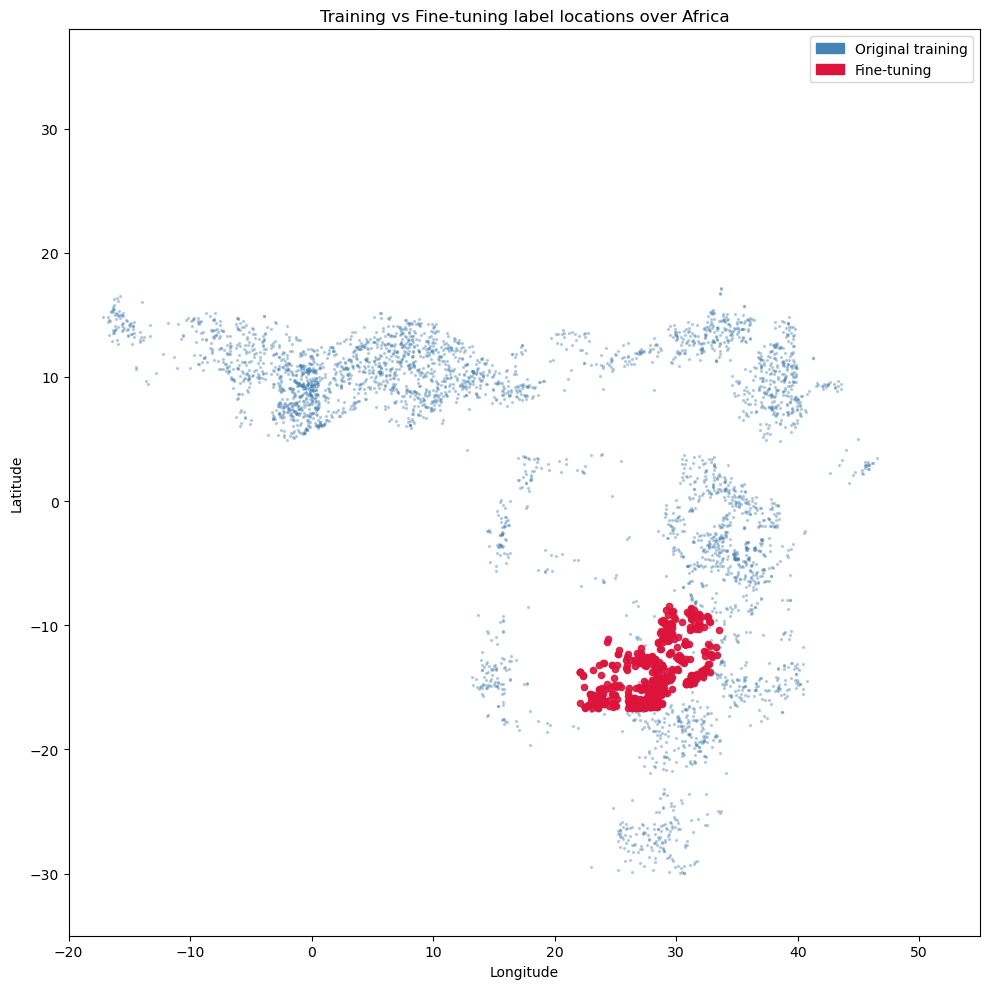

In [28]:
# Answer here (plot the points from the fine-tuning and original training
# catalog on map of Africa, 2.5 points)
# Plot fine-tuning vs original training catalog points on Africa map
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import pandas as pd

# Load both catalogs
orig_catalog  = pd.read_csv("./mappingafrica-256/catalog.csv")
ft_catalog    = pd.read_csv("./finetune_mappingafrica_256/mappingafrica-finetune_catalog.csv")  # adjust path

fig, ax = plt.subplots(figsize=(10, 10))

# Plot original training points
ax.scatter(
    orig_catalog["x"], orig_catalog["y"],
    s=2, alpha=0.3, color="steelblue", label="Original training"
)

# Plot fine-tuning points (larger so they stand out)
ax.scatter(
    ft_catalog["x"], ft_catalog["y"],
    s=20, alpha=0.9, color="crimson", label="Fine-tuning"
)

ax.set_xlim(-20, 55)
ax.set_ylim(-35, 38)
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.set_title("Training vs Fine-tuning label locations over Africa")
ax.legend(handles=[
    mpatches.Patch(color="steelblue", label="Original training"),
    mpatches.Patch(color="crimson",   label="Fine-tuning"),
])
plt.tight_layout()
plt.show()

In [29]:
# Answer here (freezing encoder, 5 points)
# Freeze encoder, define optimizer and loss
num_classes = 3

for name, param in model.named_parameters():
    if "enc" in name:          # matches enc1..enc5 and pool layers
        param.requires_grad = False

# Confirm which layers are frozen vs trainable
for name, param in model.named_parameters():
    print(f"{'TRAINABLE' if param.requires_grad else 'FROZEN   '} | {name}")

optimizer = torch.optim.Adam(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=1e-4
)
criterion = torch.nn.CrossEntropyLoss()
num_finetune_epochs = 10


FROZEN    | enc1.conv.0.weight
FROZEN    | enc1.conv.0.bias
FROZEN    | enc1.conv.1.weight
FROZEN    | enc1.conv.1.bias
FROZEN    | enc1.conv.3.weight
FROZEN    | enc1.conv.3.bias
FROZEN    | enc1.conv.4.weight
FROZEN    | enc1.conv.4.bias
FROZEN    | enc2.conv.0.weight
FROZEN    | enc2.conv.0.bias
FROZEN    | enc2.conv.1.weight
FROZEN    | enc2.conv.1.bias
FROZEN    | enc2.conv.3.weight
FROZEN    | enc2.conv.3.bias
FROZEN    | enc2.conv.4.weight
FROZEN    | enc2.conv.4.bias
FROZEN    | enc3.conv.0.weight
FROZEN    | enc3.conv.0.bias
FROZEN    | enc3.conv.1.weight
FROZEN    | enc3.conv.1.bias
FROZEN    | enc3.conv.3.weight
FROZEN    | enc3.conv.3.bias
FROZEN    | enc3.conv.4.weight
FROZEN    | enc3.conv.4.bias
FROZEN    | enc4.conv.0.weight
FROZEN    | enc4.conv.0.bias
FROZEN    | enc4.conv.1.weight
FROZEN    | enc4.conv.1.bias
FROZEN    | enc4.conv.3.weight
FROZEN    | enc4.conv.3.bias
FROZEN    | enc4.conv.4.weight
FROZEN    | enc4.conv.4.bias
FROZEN    | enc5.conv.0.weight
FROZEN   

In [32]:
# Step 1: Fix the catalog paths
ft_catalog = pd.read_csv("./finetune_mappingafrica_256/mappingafrica-finetune_catalog.csv")

ft_catalog["window_b"] = ft_catalog["window_b"].apply(
    lambda p: "./finetune_mappingafrica_256/" + p
)
ft_catalog["mask"] = ft_catalog["mask"].apply(
    lambda p: "./finetune_mappingafrica_256/" + p
)

# Verify
print(ft_catalog["window_b"].iloc[0])
print(f"Exists: {os.path.exists(ft_catalog['window_b'].iloc[0])}")

./finetune_mappingafrica_256/mappingafrica-256/images/ZM1622949_2021-08.tif
Exists: True


In [35]:
# Step 2: Save fixed catalog
ft_catalog.to_csv("./finetune_mappingafrica_256/catalog_fixed.csv", index=False)
ft_csv = "./finetune_mappingafrica_256/catalog_fixed.csv"
print("Fixed catalog saved.")
print(ft_catalog["split"].value_counts())  # check train/validate/test counts

Fixed catalog saved.
split
train       500
validate    100
test         50
Name: count, dtype: int64


In [41]:
ft_csv = "./finetune_mappingafrica_256/catalog_fixed.csv"

ft_train_dataset = ActiveLoadingDataset(
    src_dir="./",
    csv_path=ft_csv,
    split="train",
    apply_normalization=True,
    transform=["rotate","flip"])
ft_val_dataset   = ActiveLoadingDataset(src_dir="./", csv_path=ft_csv, split="validate",
                                         apply_normalization=True, transform=None)
ft_test_dataset  = ActiveLoadingDataset(src_dir="./", csv_path=ft_csv, split="test",
                                         apply_normalization=True, transform=None)

ft_train_loader = DataLoader(ft_train_dataset, batch_size=4, shuffle=True, num_workers=0)

print(f"Train: {len(ft_train_dataset)} | Val: {len(ft_val_dataset)} | Test: {len(ft_test_dataset)}")

Train: 500 | Val: 100 | Test: 50


In [ ]:
# # Step 3: Recreate datasets with fixed catalog
# ft_train_dataset = ActiveLoadingDataset(
#     src_dir="./",
#     csv_path=ft_csv,
#     split="train",
#     apply_normalization=True,
#     transform=["rotate", "flip"],
# )
# ft_val_dataset = ActiveLoadingDataset(
#     src_dir="./",
#     csv_path=ft_csv,
#     split="validate",
#     apply_normalization=True,
#     transform=None,
# )
# ft_test_dataset = ActiveLoadingDataset(
#     src_dir="./",
#     csv_path=ft_csv,
#     split="test",
#     apply_normalization=True,
#     transform=None,
# )

# print(f"Train: {len(ft_train_dataset)} | Val: {len(ft_val_dataset)} | Test: {len(ft_test_dataset)}")

Train: 500 | Val: 100 | Test: 50


In [37]:
# Step 4: Test one batch
ft_train_loader = DataLoader(ft_train_dataset, batch_size=4, shuffle=True, num_workers=0)
images, labels, paths = next(iter(ft_train_loader))
print(f"Batch loaded - images: {images.shape}, labels: {labels.shape}")
print(f"Sample path: {paths[0]}")

Batch loaded - images: torch.Size([4, 4, 256, 256]), labels: torch.Size([4, 256, 256])
Sample path: ./finetune_mappingafrica_256/mappingafrica-256/images/ZM1221191_2021-08.tif


In [47]:
ft_csv = "./finetune_mappingafrica_256/catalog_fixed.csv"

ft_train_dataset = ActiveLoadingDataset(src_dir="./", csv_path=ft_csv, split="train",
                                         apply_normalization=True, transform=["rotate","flip"])
ft_val_dataset   = ActiveLoadingDataset(src_dir="./", csv_path=ft_csv, split="validate",
                                         apply_normalization=True, transform=None)
ft_test_dataset  = ActiveLoadingDataset(src_dir="./", csv_path=ft_csv, split="test",
                                         apply_normalization=True, transform=None)

ft_train_loader = DataLoader(ft_train_dataset, batch_size=4, shuffle=True, num_workers=0)

# Test immediately
images, labels, paths = next(iter(ft_train_loader))
print(f"Success! images: {images.shape}, labels: {labels.shape}")

Success! images: torch.Size([4, 4, 256, 256]), labels: torch.Size([4, 256, 256])


In [48]:

ft_train_loader = DataLoader(ft_train_dataset, batch_size=32, shuffle=True)
ft_val_loader   = DataLoader(ft_val_dataset,   batch_size=32, shuffle=False)

print(f"Train batches: {len(ft_train_loader)} | Val batches: {len(ft_val_loader)}")

Train batches: 16 | Val batches: 4


In [49]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")  # confirm it says cuda

# Fine-tuning training loop
model = model.to(device)

for epoch in range(num_finetune_epochs):

    # ── Training phase ──────────────────────────────────────────────────────
    model.train()
    train_loss = 0.0

    for images, labels, _ in ft_train_loader:
        images = images.to(device)
        labels = labels.to(device).long()

        optimizer.zero_grad()
        outputs = model(images)
        loss    = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        train_loss += loss.item()

    avg_train_loss = train_loss / len(ft_train_loader)

    # ── Validation phase ─────────────────────────────────────────────────────
    model.eval()
    val_loss = 0.0

    evaluator = Evaluator(num_class=num_classes)
    evaluator.reset()

    with torch.no_grad():
        for images, labels, _ in ft_val_loader:
            images = images.to(device)
            labels = labels.to(device).long()

            outputs = model(images)
            loss    = criterion(outputs, labels)
            val_loss += loss.item()

            preds = torch.argmax(outputs, dim=1)
            evaluator.add_batch(labels.cpu().numpy(), preds.cpu().numpy())

    avg_val_loss = val_loss / len(ft_val_loader)
    val_acc      = evaluator.Pixel_Accuracy()
    val_miou     = evaluator.Mean_Intersection_over_Union()

    print(
        f"[Fine-tune] Epoch {epoch+1}/{num_finetune_epochs} | "
        f"Train Loss: {avg_train_loss:.4f} | "
        f"Val Loss: {avg_val_loss:.4f} | "
        f"Val Acc: {val_acc:.4f} | "
        f"Val mIoU: {val_miou:.4f}"
    )

Using device: cuda
[Fine-tune] Epoch 1/10 | Train Loss: 0.5446 | Val Loss: 0.5567 | Val Acc: 0.7891 | Val mIoU: 0.3994
[Fine-tune] Epoch 2/10 | Train Loss: 0.5035 | Val Loss: 0.5133 | Val Acc: 0.8018 | Val mIoU: 0.4072
[Fine-tune] Epoch 3/10 | Train Loss: 0.4776 | Val Loss: 0.4811 | Val Acc: 0.8147 | Val mIoU: 0.4099
[Fine-tune] Epoch 4/10 | Train Loss: 0.4597 | Val Loss: 0.4809 | Val Acc: 0.8091 | Val mIoU: 0.4126
[Fine-tune] Epoch 5/10 | Train Loss: 0.4486 | Val Loss: 0.4626 | Val Acc: 0.8181 | Val mIoU: 0.4109
[Fine-tune] Epoch 6/10 | Train Loss: 0.4458 | Val Loss: 0.4538 | Val Acc: 0.8224 | Val mIoU: 0.4136
[Fine-tune] Epoch 7/10 | Train Loss: 0.4408 | Val Loss: 0.4587 | Val Acc: 0.8190 | Val mIoU: 0.4148
[Fine-tune] Epoch 8/10 | Train Loss: 0.4320 | Val Loss: 0.4555 | Val Acc: 0.8188 | Val mIoU: 0.4116
[Fine-tune] Epoch 9/10 | Train Loss: 0.4272 | Val Loss: 0.4503 | Val Acc: 0.8193 | Val mIoU: 0.4154
[Fine-tune] Epoch 10/10 | Train Loss: 0.4229 | Val Loss: 0.4456 | Val Acc: 0.8210

Example output

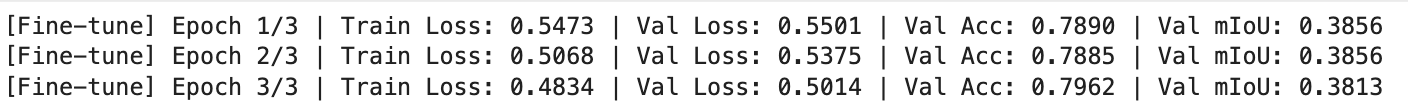

In [50]:
# Answer here (save finetuned model, 2.5 points)

# Save the fine-tuned model
import os
os.makedirs("./checkpoints", exist_ok=True)
save_path = "./checkpoints/unet_finetuned.pth"
torch.save(model.state_dict(), save_path)
print(f"Fine-tuned model saved to: {save_path}")

Fine-tuned model saved to: ./checkpoints/unet_finetuned.pth


#### Step 2.4: Run Inference and Generate Segmentation Predictions

After fine-tuning your UNet model, you will now evaluate it on the test dataset.

In this step, you will:

- Switch the model to evaluation mode

- Run inference using torch.no_grad()

- Generate and save segmentation predictions

- print overall accuracy and MIoU


> **Note**:
> This procedure for inference differs than the approach one would use for
> making maps. **In what way do you think this differs?**


In [57]:
def do_prediction(test_loader, model, num_classes, device, save_dir):
    save_dir = Path(save_dir)
    save_dir_hard = save_dir / "HardScore"
    os.makedirs(save_dir_hard, exist_ok=True)

    model = model.to(device)
    model.eval()

    evaluator = Evaluator(num_class=num_classes)
    evaluator.reset()

    print("--------- Start Inference (Prediction on Test dataset) -----------")

    with torch.no_grad():
        for images, labels, img_paths in test_loader:
            images = images.to(device)
            labels = labels.to(device).long()

            outputs = model(images)
            probs = torch.nn.functional.softmax(outputs, dim=1)
            preds = torch.argmax(probs, dim=1)

            evaluator.add_batch(labels.cpu().numpy(), preds.cpu().numpy())

            for i in range(preds.shape[0]):
                src_path = img_paths[i]
                pred_np  = preds[i].cpu().numpy().astype(np.uint8)

                with rasterio.open(src_path) as src:
                    profile = src.profile.copy()

                # ✅ nodata=None fixes the -32768 uint8 error
                profile.update(
                    count=1,
                    dtype=rasterio.uint8,
                    compress="lzw",
                    nodata=None,
                )

                out_name = Path(src_path).stem + "_pred.tif"
                out_path = save_dir_hard / out_name

                with rasterio.open(out_path, "w", **profile) as dst:
                    dst.write(pred_np, 1)

                print(f"Saved: {out_path}")

    overall_acc = evaluator.Pixel_Accuracy()
    miou        = evaluator.Mean_Intersection_over_Union()

    print(f"Overall Pixel Accuracy: {overall_acc:.4f}")
    print(f"Mean IoU (mIoU):        {miou:.4f}")
    print("--------------------- Inference Finished ---------------------")

In [52]:
# Load fine-tuned model and run inference
device     = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model_path = "./checkpoints/unet_finetuned.pth"
model.load_state_dict(torch.load(model_path, map_location=device))
model = model.to(device)
print("Loaded fine-tuned model.")

save_dir = "./predictions"

C:\Users\bikal\AppData\Local\Temp\ipykernel_4784\3182182654.py:4: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(model_path, map_location=dev

Loaded fine-tuned model.


In [58]:
do_prediction(ft_test_loader, model, num_classes=3, device=device, save_dir=save_dir)

--------- Start Inference (Prediction on Test dataset) -----------
Saved: predictions\HardScore\ZM1622949_2021-08_pred.tif
Saved: predictions\HardScore\ZM1634599_2021-08_pred.tif
Saved: predictions\HardScore\ZM1634645_2021-08_pred.tif
Saved: predictions\HardScore\ZM1656379_2021-08_pred.tif
Saved: predictions\HardScore\ZM1702968_2021-08_pred.tif
Saved: predictions\HardScore\ZM1706637_2021-08_pred.tif
Saved: predictions\HardScore\ZM1712155_2021-08_pred.tif
Saved: predictions\HardScore\ZM1716286_2021-08_pred.tif
Saved: predictions\HardScore\ZM1717612_2021-08_pred.tif
Saved: predictions\HardScore\ZM1719919_2021-08_pred.tif
Saved: predictions\HardScore\ZM1829067_2021-08_pred.tif
Saved: predictions\HardScore\ZM1841419_2021-08_pred.tif
Saved: predictions\HardScore\ZM1858604_2021-08_pred.tif
Saved: predictions\HardScore\ZM1888408_2021-08_pred.tif
Saved: predictions\HardScore\ZM1911527_2021-08_pred.tif
Saved: predictions\HardScore\ZM1921657_2021-08_pred.tif
Saved: predictions\HardScore\ZM193334

#### Step 2.5: Plot a set of image, label, and prediction.

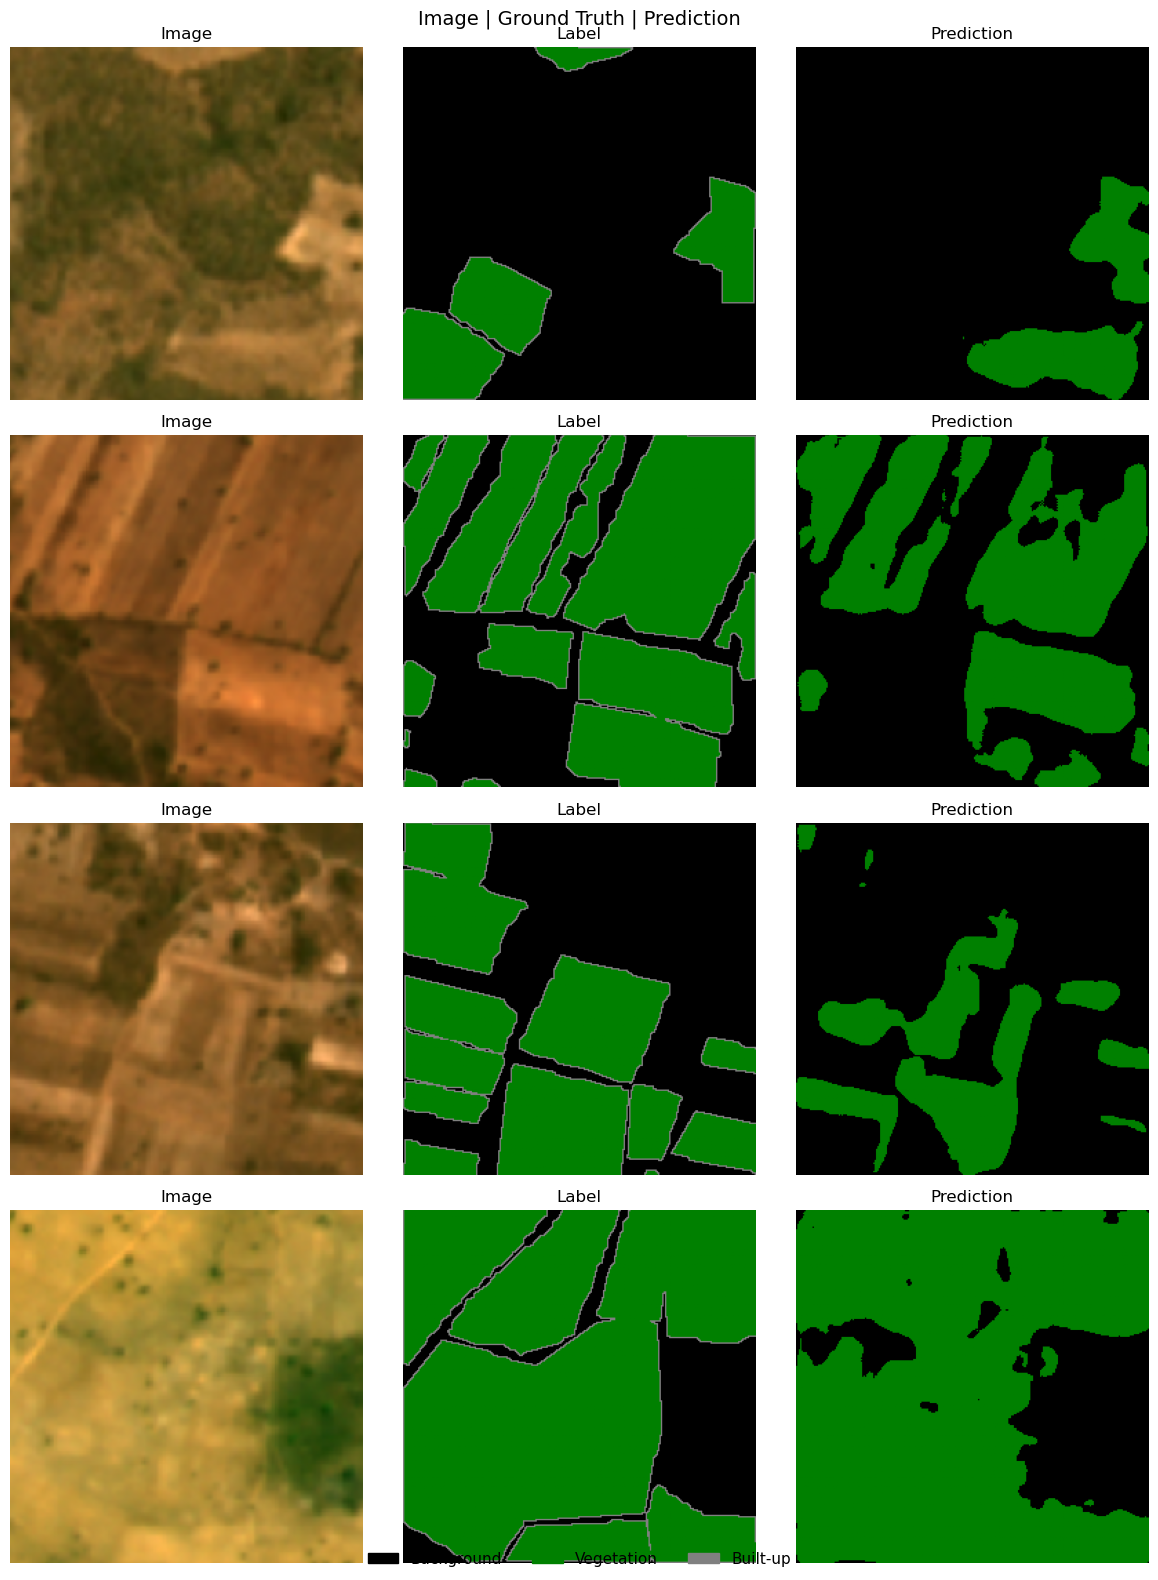

In [ ]:


# Load fixed catalog to get correct paths
ft_catalog = pd.read_csv(ft_csv)

# Fix paths same way as dataset
ft_catalog["window_b"] = ft_catalog["window_b"].apply(
    lambda p: os.path.join("./finetune_mappingafrica_256", p) if not os.path.exists(p) else p
)
ft_catalog["mask"] = ft_catalog["mask"].apply(
    lambda p: os.path.join("./finetune_mappingafrica_256", p) if not os.path.exists(p) else p
)

# Get test split only
test_catalog = ft_catalog[ft_catalog["split"] == "test"].reset_index(drop=True)

# Class color map
cmap   = mcolors.ListedColormap(["black", "green", "gray"])
bounds = [0, 1, 2, 3]
norm   = mcolors.BoundaryNorm(bounds, cmap.N)
class_labels = ["Background", "Vegetation", "Built-up"]

pred_dir   = Path(save_dir) / "HardScore"
pred_paths = sorted(pred_dir.glob("*_pred.tif"))[:4]

fig, axes = plt.subplots(len(pred_paths), 3, figsize=(12, 4 * len(pred_paths)))

for row, pred_path in enumerate(pred_paths):
    # Match prediction back to catalog row by stem name
    stem = pred_path.stem.replace("_pred", "")
    match = test_catalog[test_catalog["window_b"].str.contains(stem)]

    if match.empty:
        print(f"No match found for {stem}, skipping.")
        continue

    img_path = match["window_b"].iloc[0]
    lbl_path = match["mask"].iloc[0]

    # Image (RGB from bands 1,2,3)
    with rasterio.open(img_path) as src:
        rgb = src.read([1, 2, 3]).transpose(1, 2, 0).astype(float)
    rgb = (rgb - rgb.min()) / (rgb.max() - rgb.min() + 1e-8)

    # Label
    with rasterio.open(lbl_path) as src:
        label = src.read(1)

    # Prediction
    with rasterio.open(pred_path) as src:
        pred = src.read(1)

    ax_img, ax_lbl, ax_pred = axes[row] if len(pred_paths) > 1 else axes

    ax_img.imshow(rgb)
    ax_img.set_title("Image")
    ax_img.axis("off")

    ax_lbl.imshow(label, cmap=cmap, norm=norm)
    ax_lbl.set_title("Label")
    ax_lbl.axis("off")

    ax_pred.imshow(pred, cmap=cmap, norm=norm)
    ax_pred.set_title("Prediction")
    ax_pred.axis("off")

legend_handles = [Patch(color=cmap(norm(c)), label=class_labels[c]) for c in range(len(class_labels))]
fig.legend(handles=legend_handles, loc="lower center", ncol=len(class_labels), fontsize=11, frameon=False)
plt.suptitle("Image | Ground Truth | Prediction", fontsize=14)
plt.tight_layout()
plt.show()

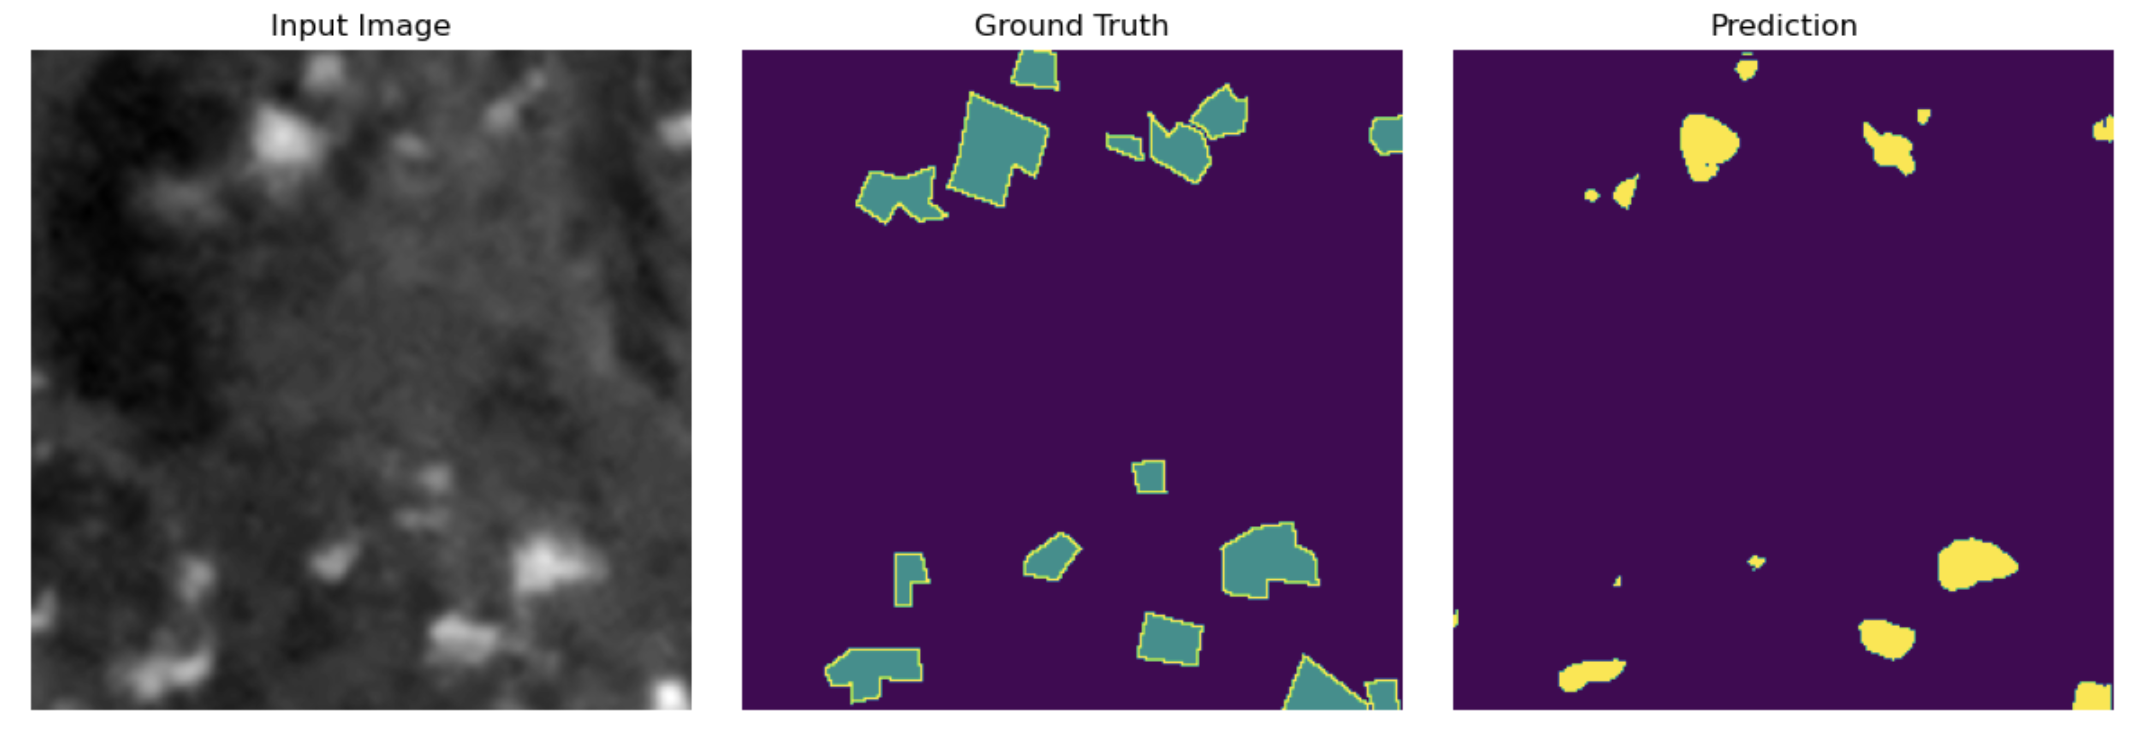